### 1. Modelos com variáveis dependentes limitadas e correções de seleção amostral

O conjunto de códigos abaixo replica os exemplos práticos do Capítulo 17, intitulado **"Modelos com variáveis dependentes limitadas e correções de seleção amostral"**, do livro *Introdução à Econometria*, tradução da 6º edição Norte Americana, do autor Jeffrey M. Wooldridge. Este capítulo discute a aplicação de modelos de resposta binária, com foco nos modelos Logit, Probit e Mínimos Quadrados Ponderados (MPL), que são amplamente utilizados para analisar variáveis dependentes binárias. O modelo Logit utiliza a função logística para modelar a probabilidade de ocorrência de um evento, sendo fácil de interpretar, já que seus coeficientes estão diretamente relacionados às odds de ocorrência do evento. Por outro lado, o modelo Probit, que usa a função de distribuição acumulada normal, pode ser mais adequado quando se assume uma distribuição normal subjacente para os erros, embora a interpretação dos coeficientes seja mais complexa. O MPL, embora não seja especificamente desenhado para variáveis binárias, pode ser aplicado nesse contexto, mas tende a gerar previsões fora do intervalo [0,1], o que limita sua aplicabilidade. Enquanto o Logit e o Probit garantem previsões dentro do intervalo desejado, o MPL, ao ser mais simples, pode não ser a melhor escolha em termos de precisão e consistência para dados binários.. O livro, em formato digital e físico, pode ser adquirido no seguinte site: [amazon.com.br](https://www.amazon.com.br/Introdu%C3%A7%C3%A3o-%C3%A0-econometria-abordagem-moderna/dp/8522125643?ref_=ast_author_dp&dib=eyJ2IjoiMSJ9.xpLzGp_gZEtZm2kFmBCS0if6iw5aeB-m4qX1SKcoLrzW2xj1vkpOLp1CDoM7qPymZwglN1USzM69oUsMlZMlc8hm2kJEe2SLc4ft_i_GErH5YT2BZepNJLVH2D1cAGzU3WfbeyFYrMs4djQeG0V0I3MA2aVgo4IqjdGSKZzvuHkfd18qWqoBjSYovRqPNAU0sI9kwF6RwGG2EatJQ0LuUUOSw_OTKr29SeqG01Y7cds.zp4BJt5PaAnnWcFufRwtdk6xs-2WFdGq2UM5uH3Xrbc&dib_tag=AUTHOR).

### 2. Bibliotecas

In [2]:
# Manipulação dos dados
import pandas as pd
import numpy as np

# Estatística
import statsmodels.formula.api as smf
import statsmodels.api as sm
import patsy as pt
import scipy.stats as stats
import statsmodels.base.model as smclass

# Dados
import wooldridge as woo

# Configurações
import warnings
from tabulate import tabulate

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
warnings.filterwarnings("ignore")

### Exemplo 17.1 Participação das mulheres casadas na força de trabalho

In [84]:
# Importando os dados
mroz = woo.dataWoo("mroz")
mroz.head()

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,huseduc,huswage,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
0,1,1610,1,0,32,12,3.3540,2.65,2708,34,12,4.0288,16310.0,0.7215,12,7,5.0,0,14,10.910060,1.210154,196
1,1,1656,0,2,30,12,1.3889,2.65,2310,30,9,8.4416,21800.0,0.6615,7,7,11.0,1,5,19.499981,0.328512,25
2,1,1980,1,3,35,12,4.5455,4.04,3072,40,12,3.5807,21040.0,0.6915,12,7,5.0,0,15,12.039910,1.514138,225
3,1,456,0,3,34,12,1.0965,3.25,1920,53,10,3.5417,7300.0,0.7815,7,7,5.0,0,6,6.799996,0.092123,36
4,1,1568,1,2,31,14,4.5918,3.60,2000,32,12,10.0000,27300.0,0.6215,12,14,9.5,1,7,20.100058,1.524272,49


In [85]:
# Formato dos dados
mroz.shape

(753, 22)

In [86]:
# Dados faltantes por coluna
mroz.isna().sum()

inlf          0
hours         0
kidslt6       0
kidsge6       0
age           0
educ          0
wage        325
repwage       0
hushrs        0
husage        0
huseduc       0
huswage       0
faminc        0
mtr           0
motheduc      0
fatheduc      0
unem          0
city          0
exper         0
nwifeinc      0
lwage       325
expersq       0
dtype: int64

##### Modelo de Probabilidade Linear (MPL)

Os dados indicam que, mantendo as demais variáveis iguais a zero (por exemplo, sem experiência de trabalho, idade de 0 anos **(o que é extremamente irreal)** e sem filhos), a probabilidade de participação das mulheres na força de trabalho é de 58,55%. Vale ressaltar que o valor do intercepto, isoladamente, pode não ser muito útil, pois dificilmente todas as variáveis atingem exatamente zero em situações reais (como experiência de trabalho igual a zero ou idade de 0 anos). Portanto, sua interpretação é mais teórica, servindo de base para compreender a influência das variáveis independentes no modelo.

Os coeficientes indicam o seguinte:

-O coeficiente de nwifeinc (-0,0034) sugere que, para cada aumento unitário na renda do cônjuge, a probabilidade de participação na força de trabalho diminui em 0,34%.

-O coeficiente de educ (0,0380) indica que, para cada aumento de uma unidade no número de anos de escolaridade da mulher, a probabilidade de ela estar na força de trabalho aumenta em 3,8%.

In [87]:
# Ajusta o modelo
reg_mpl = smf.ols(formula='inlf ~ nwifeinc + educ + exper + expersq + age + kidslt6 + kidsge6', data=mroz)
results_mpl = reg_mpl.fit(cov_type='HC3')

# Exibindo o resumo dos resultados
print(results_mpl.summary())

                            OLS Regression Results                            
Dep. Variable:                   inlf   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     61.35
Date:                Mon, 10 Feb 2025   Prob (F-statistic):           1.55e-69
Time:                        20:35:35   Log-Likelihood:                -423.89
No. Observations:                 753   AIC:                             863.8
Df Residuals:                     745   BIC:                             900.8
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5855      0.154      3.812      0.0

O modelo acertou 73,44% das previsões sobre a participação das mulheres no mercado de trabalho.

In [88]:
# Gerar as previsões com o modelo ajustado
predictions = results_mpl.predict()

# Aplicar uma threshold de 0.5 para classificar as previsões
predicted_classes = (predictions >= 0.5).astype(int)

# Obter os valores reais de 'inlf' no conjunto de dados
actual_classes = mroz['inlf']

# Calcular o número de previsões corretas
correct_predictions = np.sum(predicted_classes == actual_classes)

# Calcular a porcentagem de previsões corretas
accuracy = correct_predictions / len(actual_classes) * 100

print(f'Porcentagem de previsões corretas: {accuracy:.2f}%')

Porcentagem de previsões corretas: 73.44%


##### Modelo LOGIT

A interpretação dos coeficientes dos modelos logit e probit é semelhante à do modelo de probabilidade linear quando analisados de forma totalmente independente. **Contudo, é importante enfatizar que as magnitudes das estimativas dos coeficientes entre esses modelos não são diretamente comparáveis.** (Os coeficientes estimados em cada modelo não são diretamente comparáveis entre si, porque cada modelo tem uma estrutura diferente de distribuição (normal para o probit, logística para o logit, e linear para o LPM))

In [89]:
# Ajustando o modelo
reg_logit = smf.logit(formula='inlf ~ nwifeinc + educ + exper + expersq + age + kidslt6 + kidsge6', data=mroz)
resultado_logit = reg_logit.fit(disp=0)

# Exibindo os resultados
print(resultado_logit.summary())

                           Logit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                          Logit   Df Residuals:                      745
Method:                           MLE   Df Model:                            7
Date:                Mon, 10 Feb 2025   Pseudo R-squ.:                  0.2197
Time:                        20:35:36   Log-Likelihood:                -401.77
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 3.159e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4255      0.860      0.494      0.621      -1.261       2.112
nwifeinc      -0.0213      0.008     -2.535      0.011      -0.038      -0.005
educ           0.2212      0.043      5.091      0.0

In [90]:
# Gerar as previsões com o modelo ajustado
predictions = resultado_logit.predict()

# Aplicar uma threshold de 0.5 para classificar as previsões
predicted_classes = (predictions >= 0.5).astype(int)

# Obter os valores reais de 'inlf' no conjunto de dados
actual_classes = mroz['inlf']

# Calcular o número de previsões corretas
correct_predictions = np.sum(predicted_classes == actual_classes)

# Calcular a porcentagem de previsões corretas
accuracy = correct_predictions / len(actual_classes) * 100

print(f'Porcentagem de previsões corretas: {accuracy:.2f}%')

Porcentagem de previsões corretas: 73.57%


##### Modelo PROBIT

In [91]:
# Ajustando o modelo
reg_probit = smf.probit(formula='inlf ~ nwifeinc + educ + exper + expersq + age + kidslt6 + kidsge6', data=mroz)
resultado_probit = reg_probit.fit(disp=0)

# Exibindo os resultados
print(resultado_probit.summary())

                          Probit Regression Results                           
Dep. Variable:                   inlf   No. Observations:                  753
Model:                         Probit   Df Residuals:                      745
Method:                           MLE   Df Model:                            7
Date:                Mon, 10 Feb 2025   Pseudo R-squ.:                  0.2206
Time:                        20:35:37   Log-Likelihood:                -401.30
converged:                       True   LL-Null:                       -514.87
Covariance Type:            nonrobust   LLR p-value:                 2.009e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2701      0.509      0.531      0.595      -0.727       1.267
nwifeinc      -0.0120      0.005     -2.484      0.013      -0.022      -0.003
educ           0.1309      0.025      5.183      0.0

In [92]:
# Gerar as previsões com o modelo ajustado
predictions = resultado_probit.predict()

# Aplicar uma threshold de 0.5 para classificar as previsões
predicted_classes = (predictions >= 0.5).astype(int)

# Obter os valores reais de 'inlf' no conjunto de dados
actual_classes = mroz['inlf']

# Calcular o número de previsões corretas
correct_predictions = np.sum(predicted_classes == actual_classes)

# Calcular a porcentagem de previsões corretas
accuracy = correct_predictions / len(actual_classes) * 100

print(f'Porcentagem de previsões corretas: {accuracy:.2f}%')

Porcentagem de previsões corretas: 73.44%


##### Tabela 17.2 Efeitos parciais médios

O código abaixo foi elaborado com base nos códigos apresentados no livro Using R, Python, and Julia for Introductory Econometrics (2ª edição), de Florian Heiss e Daniel Brunner.

In [93]:
# Carregar os dados
mroz = woo.dataWoo('mroz')

# Estimar os modelos
reg_lin = smf.ols(formula='inlf ~ nwifeinc + educ + exper + expersq + age + kidslt6 + kidsge6', data=mroz)
results_lin = reg_lin.fit(cov_type='HC3')

reg_logit = smf.logit(formula='inlf ~ nwifeinc + educ + exper + I(exper**2) + age + kidslt6 + kidsge6', data=mroz)
results_logit = reg_logit.fit(disp=0)

reg_probit = smf.probit(formula='inlf ~ nwifeinc + educ + exper + I(exper**2) + age + kidslt6 + kidsge6', data=mroz)
results_probit = reg_probit.fit(disp=0)

# Coeficientes e erros padrão do MPL
coef_names = np.array(results_lin.model.exog_names)
coef_names = np.delete(coef_names, 0)  # Remover o Intercept

# Efeitos parciais médios (APEs) para Logit e Probit
marg_eff_logit = results_logit.get_margeff()
marg_eff_probit = results_probit.get_margeff()

APE_logit = marg_eff_logit.margeff
SE_logit = marg_eff_logit.margeff_se  # Erros padrão do Logit

APE_probit = marg_eff_probit.margeff
SE_probit = marg_eff_probit.margeff_se  # Erros padrão do Probit

# Coeficientes e erros padrão do MPL
MPL_coef = results_lin.params[1:].values  # Remove o Intercept
MPL_se = results_lin.bse[1:].values       # Erros padrão robustos (HC3)

# Criar a tabela formatada
tabela_formatada = []
for var, mpl_c, mpl_s, logit_c, logit_s, probit_c, probit_s in zip(
    coef_names, MPL_coef, MPL_se, APE_logit, SE_logit, APE_probit, SE_probit
):
    tabela_formatada.append([
        var,
        f'{mpl_c:.4f}\n({mpl_s:.4f})',
        f'{logit_c:.4f}\n({logit_s:.4f})',
        f'{probit_c:.4f}\n({probit_s:.4f})'
    ])

# Cabeçalho da tabela
headers = ['Variável', 'MPL', 'Logit (APE)', 'Probit (APE)']

# Exibir a tabela formatada
print(tabulate(tabela_formatada, headers=headers, tablefmt='plain'))

Variável    MPL       Logit (APE)    Probit (APE)
nwifeinc    -0.0034   -0.0038        -0.0036
            (0.0016)  (0.0015)       (0.0014)
educ        0.0380    0.0395         0.0394
            (0.0073)  (0.0073)       (0.0072)
exper       0.0395    0.0368         0.0371
            (0.0060)  (0.0052)       (0.0052)
expersq     -0.0006   -0.0006        -0.0006
            (0.0002)  (0.0002)       (0.0002)
age         -0.0161   -0.0157        -0.0159
            (0.0024)  (0.0024)       (0.0024)
kidslt6     -0.2618   -0.2578        -0.2612
            (0.0322)  (0.0319)       (0.0319)
kidsge6     0.0130    0.0107         0.0108
            (0.0137)  (0.0133)       (0.0131)


### Exemplo 17.2 Oferta de mão de obra anual de mulheres casadas

Contexto: O arquivo MROZ dados sobre horas trabalhadas de 753 mulheres casadas, 428 das quais trabalharam fora de casa por um salário durante o ano; 325 mulheres trabalharam zero horas. Para as mulheres que trabalharam horas postivas a faixa é partante ampla, de 12 a 4950. Assim, horas anuais trabalhadas é uma boa candidata ao modelo tobit.

In [94]:
# Importando os dados
mroz = woo.dataWoo("mroz")
mroz.head()

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,huseduc,huswage,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
0,1,1610,1,0,32,12,3.3540,2.65,2708,34,12,4.0288,16310.0,0.7215,12,7,5.0,0,14,10.910060,1.210154,196
1,1,1656,0,2,30,12,1.3889,2.65,2310,30,9,8.4416,21800.0,0.6615,7,7,11.0,1,5,19.499981,0.328512,25
2,1,1980,1,3,35,12,4.5455,4.04,3072,40,12,3.5807,21040.0,0.6915,12,7,5.0,0,15,12.039910,1.514138,225
3,1,456,0,3,34,12,1.0965,3.25,1920,53,10,3.5417,7300.0,0.7815,7,7,5.0,0,6,6.799996,0.092123,36
4,1,1568,1,2,31,14,4.5918,3.60,2000,32,12,10.0000,27300.0,0.6215,12,14,9.5,1,7,20.100058,1.524272,49


In [95]:
# Formato dos dados
mroz.shape

(753, 22)

In [96]:
# Dados faltantes por coluna
mroz.isna().sum()

inlf          0
hours         0
kidslt6       0
kidsge6       0
age           0
educ          0
wage        325
repwage       0
hushrs        0
husage        0
huseduc       0
huswage       0
faminc        0
mtr           0
motheduc      0
fatheduc      0
unem          0
city          0
exper         0
nwifeinc      0
lwage       325
expersq       0
dtype: int64

##### Modelo de probabilidade linear

In [97]:
# Ajusta o modelo
reg_mpl = smf.ols(formula='hours ~ nwifeinc + educ + exper + expersq + age + kidslt6 + kidsge6', data=mroz)
results_mpl = reg_mpl.fit(cov_type='HC3')

# Exibindo o resumo dos resultados
print(results_mpl.summary())

                            OLS Regression Results                            
Dep. Variable:                  hours   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     45.14
Date:                Mon, 10 Feb 2025   Prob (F-statistic):           2.55e-53
Time:                        20:35:39   Log-Likelihood:                -6049.5
No. Observations:                 753   AIC:                         1.212e+04
Df Residuals:                     745   BIC:                         1.215e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1330.4824    277.357      4.797      0.0

##### TOBIT

O código abaixo foi retirado do livro Using R, Python, and Julia for Introductory Econometrics (2ª edição), de Florian Heiss e Daniel Brunner.

In [98]:
import patsy as pt
import scipy.stats as stats
import statsmodels.base.model as smclass

mroz = woo.dataWoo('mroz')
y, X = pt.dmatrices('hours ~ nwifeinc + educ + exper +'
                    'I(exper**2)+ age + kidslt6 + kidsge6',
                    data=mroz, return_type='dataframe')

# Gera solução inicial:
reg_ols = smf.ols(formula='hours ~ nwifeinc + educ + exper + I(exper**2) +'
                          'age + kidslt6 + kidsge6', data=mroz)
results_ols = reg_ols.fit()
sigma_start = np.log(sum(results_ols.resid ** 2) / len(results_ols.resid))
params_start = np.concatenate((np.array(results_ols.params), sigma_start),
                              axis=None)

# Estenda a classe statsmodels definindo nlog como obs:
class Tobit(smclass.GenericLikelihoodModel):
    # Define uma função que retorne o log de probabilidade negativo por observação
    # para um conjunto de parâmetros fornecido pelo argumento "params":
    def nloglikeobs(self, params):
        # Objetos em "self" são definidos na classe pai:
        X = self.exog
        y = self.endog
        p = X.shape[1]
        # Para detalhes sobre a implementação, consulte Wooldridge (2019), fórmula 17.22:
        beta = params[0:p]
        sigma = np.exp(params[p])
        y_hat = np.dot(X, beta)
        y_eq = (y == 0)
        y_g = (y > 0)
        ll = np.empty(len(y))
        ll[y_eq] = np.log(stats.norm.cdf(-y_hat[y_eq] / sigma))
        ll[y_g] = np.log(stats.norm.pdf((y - y_hat)[y_g] / sigma)) - np.log(sigma)
        # Retorna uma matriz de log de probabilidades para cada observação:
        return -ll

# Resultados
reg_tobit = Tobit(endog=y, exog=X)
results_tobit = reg_tobit.fit(start_params=params_start, maxiter=10000, disp=0)
print(f'results_tobit.summary(): \n{results_tobit.summary()}\n')

results_tobit.summary(): 
                                Tobit Results                                 
Dep. Variable:                  hours   Log-Likelihood:                -3819.1
Model:                          Tobit   AIC:                             7656.
Method:            Maximum Likelihood   BIC:                             7698.
Date:                Mon, 10 Feb 2025                                         
Time:                        20:35:43                                         
No. Observations:                 753                                         
Df Residuals:                     745                                         
Df Model:                           7                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       965.3050    446.428      2.162      0.031      90.323    1840.287
nwifeinc         

### Exemplo 17.3 Regressão de Poisson do número de prisões

Contexto: Aplicando o modelo de regressão de Poisson aos dados de preisões em CRIME1. A variável, narr86, é o número de vezes que um homem em 1986. Essa variável é zero para 1970 de 2725 homens na amostra, e somente oito valores de narr86 são maiores que cinco. Assim, um modelo de regressão de poisson é mais apropriado que um modelo de regressão linear. Mais uma vez, é importante enfatizar que os coeficientes do MQO e de Poisson não são diretamente comparáveis e possuem signficados diferentes.

In [19]:
# Importando os dados
crime1 =  woo.dataWoo("crime1")
crime1.head()

,narr86,nfarr86,nparr86,pcnv,avgsen,tottime,ptime86,qemp86,inc86,durat,black,hispan,born60,pcnvsq,pt86sq,inc86sq
0,0,0,0,0.38,17.600000,35.200001,12,0.0,0.0,0.0,0,0,1,0.1444,144,0.000000
1,2,2,0,0.44,0.000000,0.000000,0,1.0,0.8,0.0,0,1,0,0.1936,0,0.640000
2,1,1,0,0.33,22.799999,22.799999,0,0.0,0.0,11.0,1,0,1,0.1089,0,0.000000
3,2,2,1,0.25,0.000000,0.000000,5,2.0,8.8,0.0,0,1,1,0.0625,25,77.440002
4,1,1,0,0.00,0.000000,0.000000,0,2.0,8.1,1.0,0,0,0,0.0000,0,65.610008


In [20]:
# Formato dos dados
crime1.shape

(2725, 16)

In [21]:
# Dados faltantes
#crime1.isna().sum()

Visualizando a distribuição 

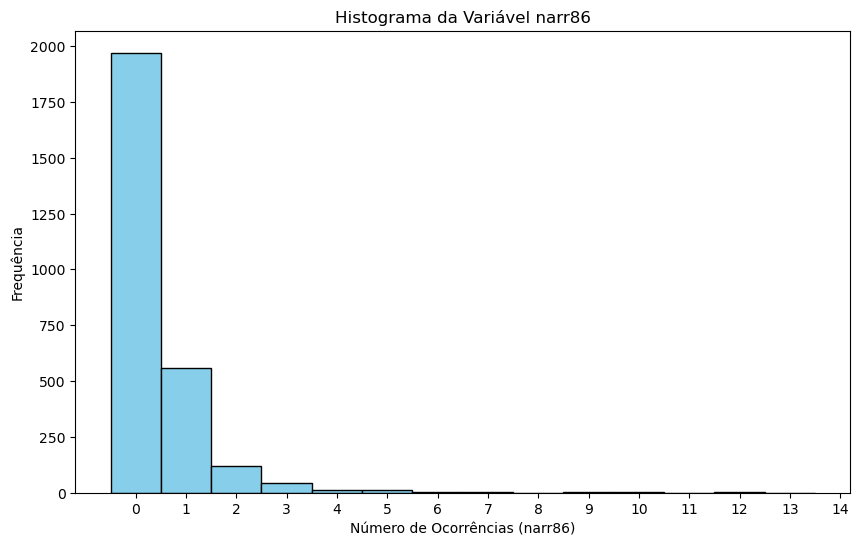

In [22]:
# Criando o histograma
plt.figure(figsize=(10, 6))
plt.hist(crime1['narr86'], bins=range(0, 15), edgecolor='black', color='skyblue', align='left')

# Personalização do gráfico
plt.title('Histograma da Variável narr86')
plt.xlabel('Número de Ocorrências (narr86)')
plt.ylabel('Frequência')
plt.xticks(range(0, 15))  # Para mostrar cada valor discreto no eixo x

plt.show()

##### Modelo linear (MQO) - (Coluna Linear (MQO))

Os erros padrão do MQO são os habituais.

In [23]:
# Variável dependente
y = crime1["narr86"]

# Variáveis independentes
X = crime1[["pcnv" , "avgsen" , "tottime" , "ptime86" , "qemp86" , "inc86" , "black" , "hispan" , "born60"]]

# Adicionando uma constante
X = sm.add_constant(X)

# Ajusta o MQO
model = sm.OLS(y, X).fit()

# Exibe os resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 narr86   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     23.57
Date:                Tue, 11 Feb 2025   Prob (F-statistic):           3.72e-39
Time:                        16:00:20   Log-Likelihood:                -3349.7
No. Observations:                2725   AIC:                             6719.
Df Residuals:                    2715   BIC:                             6778.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5766      0.038     15.215      0.0

##### Modelo Poisson

In [13]:
reg_poisson = smf.poisson(formula = 'narr86 ~ pcnv + avgsen + tottime + ptime86 + qemp86 + inc86 + black + hispan + born60',
                          data = crime1)
results_poisson = reg_poisson.fit(disp=0)
print(results_poisson.summary())

                          Poisson Regression Results                          
Dep. Variable:                 narr86   No. Observations:                 2725
Model:                        Poisson   Df Residuals:                     2715
Method:                           MLE   Df Model:                            9
Date:                Tue, 11 Feb 2025   Pseudo R-squ.:                 0.07910
Time:                        15:47:39   Log-Likelihood:                -2248.8
converged:                       True   LL-Null:                       -2441.9
Covariance Type:            nonrobust   LLR p-value:                 1.134e-77
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5996      0.067     -8.916      0.000      -0.731      -0.468
pcnv          -0.4016      0.085     -4.726      0.000      -0.568      -0.235
avgsen        -0.0238      0.020     -1.192      0.2

##### Estimação de Quasi máxima verossimilhança

O coeficiente de Poisson `pcnv` indica que $\Delta$ $pcnv = 0,10$ reduz as prisões esperadas em cerca de 4,02% $[0.402(0.1)*100]$. Como regra isso sugere que podemos reduzir o número total de prisões em cerca de 4,02% se pudermos aumentar a probabilidade de condenação em 0,1.

O coeficiente de `black` indica que, mantendo todos os demais fatores constantes, o número esperado de prisões de homens negros é aproximadamente 93,7% $(100*[esp(0,661)-1]$ maior do que o de homens brancos com os mesmos valores das outras variáveis explicativas.

In [28]:
reg_qpoisson = smf.glm(formula='narr86 ~ pcnv + avgsen + tottime + ptime86 +'
                               'qemp86 + inc86 + black + hispan + born60', 
                       data=crime1, 
                       family=sm.families.Poisson()).fit()

# Exibindo o resumo dos resultados
print(reg_qpoisson.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 narr86   No. Observations:                 2725
Model:                            GLM   Df Residuals:                     2715
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2248.8
Date:                Tue, 11 Feb 2025   Deviance:                       2822.2
Time:                        16:34:01   Pearson chi2:                 4.12e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1322
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5996      0.067     -8.916      0.0

Encontrando a estimativa da dispersão usando a estatística qui-quadrado de Pearson. Essa estimativa é importante porque permite corrigir os erros padrão da regressão de Poisson por meio desse fator. Por exemplo, um erro padrão mais confiável para o coeficiente de `tottime` seria:  

$$ 1,23 \times 0,015 = 0,0185 $$

Isso gera uma nova estatística $z$ ou $t$ de aproximadamente:  

$$\frac{0,024}{0,0185} \approx 1,30$$

De forma mais precisa:  

$$ \frac{0,024}{0,0185} = 1,2973 $$

Essa correção é útil quando há indícios de superdispersão, tornando as inferências mais robustas.

In [32]:
# Estimativa da dispersão usando a estatística qui-quadrado de Pearson
pearson_chi2 = reg_qpoisson.pearson_chi2
df_residual = reg_qpoisson.df_resid

# Cálculo de sigma_hat
sigma_hat = np.sqrt(pearson_chi2 / df_residual)
print(f"Sigma_hat: {sigma_hat:.3f}")

Sigma_hat: 1.232


### Exemplo 17.4 intervalo de reincidência

Contexto: O arquivo RECID  contém dados sobre o tempo em meses até que um ex-recluso de uma prisão da carolina do Norte seja preso depois de ser sido solto; vamos chamar de `durat`. alguns dos presidiários participaram de um programa de trabalho durante o tempo em que estiveram na prisão. também foi controlado diversas variáveis demográficas, bem como medidas de prisões e históricos criminais.

De 1445 reclusos, 893 não foram presos durante o tempo em que foram vigiados; portanto, essas observações foram censuradas. O tempo censurado diferiu entre os reclusos, variando de 70 a 81 meses.

In [33]:
# Importando os dados
recid = woo.dataWoo("recid")
recid.head()

,black,alcohol,drugs,super,married,felon,workprg,property,person,priors,educ,rules,age,tserved,follow,durat,cens,ldurat
0,0,1,0,1,1,0,1,0,0,0,7,2,441,30,72,72,1,4.276666
1,1,0,0,1,0,1,1,1,0,0,12,0,307,19,75,75,1,4.317488
2,0,0,0,0,0,0,1,1,0,0,9,5,262,27,81,9,0,2.197225
3,0,0,1,1,0,1,1,1,0,2,9,3,253,38,76,25,0,3.218876
4,0,0,1,1,0,0,0,0,0,0,9,0,244,4,81,81,1,4.394449


In [34]:
# Dados faltantes por coluna
#recid.isna().sum()

black       0
alcohol     0
drugs       0
super       0
married     0
felon       0
workprg     0
property    0
person      0
priors      0
educ        0
rules       0
age         0
tserved     0
follow      0
durat       0
cens        0
ldurat      0
dtype: int64

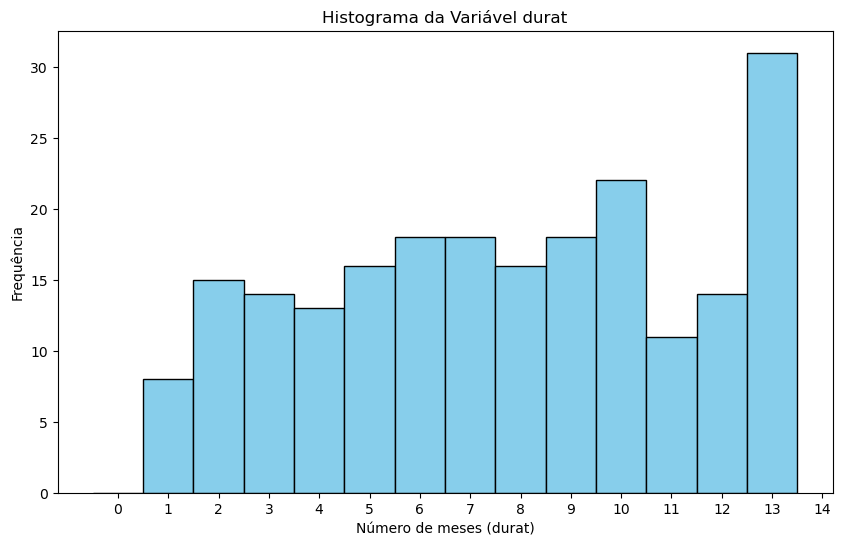

In [36]:
# Criando o histograma
plt.figure(figsize=(10, 6))
plt.hist(recid['durat'], bins=range(0, 15), edgecolor='black', color='skyblue', align='left')

# Personalização do gráfico
plt.title('Histograma da Variável durat')
plt.xlabel('Número de meses (durat)')
plt.ylabel('Frequência')
plt.xticks(range(0, 15))  # Para mostrar cada valor discreto no eixo x

plt.show()

O código abaixo foi retirado do livro Using R, Python, and Julia for Introductory Econometrics (2ª edição), de Florian Heiss e Daniel Brunner.

In [50]:
# Definir dummy para observações censuradas:
censored = recid['cens'] != 0

y, X = pt.dmatrices('ldurat ~ workprg + priors + tserved + felon +'
                    'alcohol + drugs + black + married + educ + age',
                    data=recid, return_type='dataframe')

# Gerar solução inicial:
reg_ols = smf.ols(formula='ldurat ~ workprg + priors + tserved + felon +'
                          'alcohol + drugs + black + married + educ + age',
                  data=recid)
results_ols = reg_ols.fit()
sigma_start = np.log(sum(results_ols.resid ** 2) / len(results_ols.resid))
params_start = np.concatenate((np.array(results_ols.params), sigma_start),
                              axis=None)


# Estende a classe statsmodels definindo nloglikeobs:
class CensReg(smclass.GenericLikelihoodModel):
    def __init__(self, endog, cens, exog):
        self.cens = cens
        super(smclass.GenericLikelihoodModel, self).__init__(endog, exog,
                                                             missing='none')

    def nloglikeobs(self, params):
        X = self.exog
        y = self.endog
        cens = self.cens
        p = X.shape[1]
        beta = params[0:p]
        sigma = np.exp(params[p])
        y_hat = np.dot(X, beta)
        ll = np.empty(len(y))
        # uncensored:
        ll[~cens] = np.log(stats.norm.pdf((y - y_hat)[~cens] /
                                          sigma)) - np.log(sigma)
        # censored:
        ll[cens] = np.log(stats.norm.cdf(-(y - y_hat)[cens] / sigma))
        return -ll


# Exibe os resultados
reg_censReg = CensReg(endog=y, exog=X, cens=censored)
results_censReg = reg_censReg.fit(start_params=params_start,
                                  maxiter=10000, method='BFGS', disp=0)
print(f'results_censReg.summary(): \n{results_censReg.summary()}\n')

results_censReg.summary(): 
                               CensReg Results                                
Dep. Variable:                 ldurat   Log-Likelihood:                -1597.1
Model:                        CensReg   AIC:                             3218.
Method:            Maximum Likelihood   BIC:                             3281.
Date:                Tue, 11 Feb 2025                                         
Time:                        19:32:41                                         
No. Observations:                1445                                         
Df Residuals:                    1434                                         
Df Model:                          10                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0994      0.348     11.796      0.000       3.418       4.781
workprg       -0.0626   

### Exemplo 17.5 Equação da oferta de salário para mulheres casadas

Contexto: Aplicando a correção da seleção amostral aos dados sobre mulheres casadas contidos no arquivo MROZ.

In [45]:
# Importando os dados
mroz = woo.dataWoo("mroz")
mroz.head()

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,huseduc,huswage,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
0,1,1610,1,0,32,12,3.3540,2.65,2708,34,12,4.0288,16310.0,0.7215,12,7,5.0,0,14,10.910060,1.210154,196
1,1,1656,0,2,30,12,1.3889,2.65,2310,30,9,8.4416,21800.0,0.6615,7,7,11.0,1,5,19.499981,0.328512,25
2,1,1980,1,3,35,12,4.5455,4.04,3072,40,12,3.5807,21040.0,0.6915,12,7,5.0,0,15,12.039910,1.514138,225
3,1,456,0,3,34,12,1.0965,3.25,1920,53,10,3.5417,7300.0,0.7815,7,7,5.0,0,6,6.799996,0.092123,36
4,1,1568,1,2,31,14,4.5918,3.60,2000,32,12,10.0000,27300.0,0.6215,12,14,9.5,1,7,20.100058,1.524272,49


In [46]:
# Formato dos dados
mroz.shape

(753, 22)

In [47]:
# Verificando se há dados faltantes
mroz.isna().sum()

inlf          0
hours         0
kidslt6       0
kidsge6       0
age           0
educ          0
wage        325
repwage       0
hushrs        0
husage        0
huseduc       0
huswage       0
faminc        0
mtr           0
motheduc      0
fatheduc      0
unem          0
city          0
exper         0
nwifeinc      0
lwage       325
expersq       0
dtype: int64

In [ ]:
# Removendo dados faltantes da coluna 'lwage'
mroz = mroz.dropna(subset=['lwage'])

##### MQO

In [49]:
# Variável dependente
y = mroz["lwage"]

# Variáveis independentes
X = mroz[["educ", "exper", "expersq"]]

# Adicionando uma constante
X = sm.add_constant(X)

# Ajusta o MQO
model = sm.OLS(y, X).fit()

# Exibe os resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     26.29
Date:                Tue, 11 Feb 2025   Prob (F-statistic):           1.30e-15
Time:                        19:28:59   Log-Likelihood:                -431.60
No. Observations:                 428   AIC:                             871.2
Df Residuals:                     424   BIC:                             887.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5220      0.199     -2.628      0.0

##### Heckit

O código abaixo foi retirado do livro Using R, Python, and Julia for Introductory Econometrics (2ª edição), de Florian Heiss e Daniel Brunner.


In [51]:
mroz = woo.dataWoo('mroz')

# Passo 1
reg_probit = smf.probit(formula='inlf ~ educ + exper + I(exper**2) +'
                                'nwifeinc + age + kidslt6 + kidsge6',
                        data=mroz)
results_probit = reg_probit.fit(disp=0)
pred_inlf = results_probit.fittedvalues
mroz['inv_mills'] = stats.norm.pdf(pred_inlf) / stats.norm.cdf(pred_inlf)

In [52]:
# Passo 2
reg_heckit = smf.ols(formula='lwage ~ educ + exper + I(exper**2) + inv_mills',
                     subset=(mroz['inlf'] == 1), data=mroz)
results_heckit = reg_heckit.fit()

In [53]:
# Exibe os resultados
print(f'results_heckit.summary(): \n{results_heckit.summary()}\n')

results_heckit.summary(): 
                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     19.69
Date:                Tue, 11 Feb 2025   Prob (F-statistic):           7.14e-15
Time:                        19:39:36   Log-Likelihood:                -431.57
No. Observations:                 428   AIC:                             873.1
Df Residuals:                     423   BIC:                             893.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0